# Task 1: Universal Multi-Corruption Restoration (DAE Simple Baseline)

This notebook implements the **Simple Universal Denoising Autoencoder (DAE) Baseline** for Task 1 as specified in the assignment.

### Mathematical Formulation
The universal autoencoder maps a corrupted input $\tilde{x} \in \mathbb{R}^{3 \times 128 \times 128}$ to a restored RGB image $\hat{x}$:
$$\hat{x} = D\big(E(\tilde{x})\big)$$
where $E$ denotes the convolutional encoder compressing the input into a genuine bottleneck latent representation $z = E(\tilde{x}) \in \mathbb{R}^d$, and $D$ denotes the convolutional decoder reconstructing the clean image $\hat{x} = D(z)$.

The network is trained using a linear combination of pixel reconstruction loss and Structural Similarity Index Measure (SSIM) loss:
$$\mathcal{L}_{AE} = \alpha\,\mathcal{L}_{L1}(x,\hat{x}) + (1-\alpha)\big(1-\mathrm{SSIM}(x,\hat{x})\big)$$
where $x$ represents the clean target image, $\hat{x}$ is the reconstructed output, and $\alpha \in [0, 1]$ balances pixel fidelity and structural perceptual quality (initial value $\alpha = 0.8$).

### Workflow:
1. **Config & Environment**: Hardware detection and hyperparameter definitions ($\alpha = 0.8$, $\text{latent\_dim} = 256$, $\text{base\_channels} = 32$).
2. **Data Pipeline**: Oxford-IIIT Pet dataset with runtime dynamic corruptions (clean, salt-and-pepper, Gaussian blur, rectangular occlusion sampled with equal probability $p = 0.25$).
3. **Architecture**: Convolutional encoder-decoder (`ConvDAE`) with GroupNorm, LeakyReLU, and strided convolutions with a genuine compressed bottleneck (no unrestricted skip connections).
4. **Loss**: Composite objective $\mathcal{L}_{AE} = 0.8\,\mathcal{L}_{L1} + 0.2\,(1 - \mathrm{SSIM})$.
5. **Training & Validation**: Multi-epoch training loop with automatic checkpointing (`task1_universal_ae_latest.pt` & `task1_universal_ae_best.pt`).
6. **Evaluation & Visualization**: Visual restoration inspection grid and transition gate checks before Optuna.

In [1]:
# 1. Configuration & Hyperparameters
import os

TINY_RUN = False
TINY_SIZE = 50
BATCH_SIZE = 32
LR = 3e-4
LATENT_DIM = 256
BASE_CHANNELS = 32
DROPOUT = 0.1
ALPHA = 0.8
EPOCHS = 2 if TINY_RUN else 15
SEED = 42
USE_WANDB = bool(os.getenv("WANDB_API_KEY"))
USE_WANDB = False
WANDB_PROJECT = os.getenv("WANDB_PROJECT", "genai-assignment")
WANDB_RUN_NAME = "task1_dae_simple_baseline"


In [2]:
# 2. Imports and Environment Setup
import sys
from pathlib import Path
import torch
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

# Ensure research root is in sys.path
RESEARCH_ROOT = Path("..").resolve()
if str(RESEARCH_ROOT) not in sys.path:
    sys.path.insert(0, str(RESEARCH_ROOT))

from constants import PET_IMAGES_DIR, CHECKPOINTS_MANIFEST
from src.device_utils import get_device, device_report
from src.datasets import PetDataset
from src.models_dae import ConvDAE
from src.train_loop import train_one_epoch_dae, validate_dae, set_seed
from src.checkpoint_utils import create_checkpoint_dict, save_checkpoint

set_seed(SEED)
print("[Setup] Imports successful. Manifest path:", CHECKPOINTS_MANIFEST)

[Setup] Imports successful. Manifest path: /home/mustafa/genai-assignment-1/research/checkpoints_manifest.json


In [3]:
# 3. Device Check
device = get_device(verbose=True)
report = device_report()
print(f"[Device Report] Type: {report['device_type']}, Name: {report['device_name']}")
if torch.cuda.is_available():
    print(f"[GPU Memory] Total: {torch.cuda.get_device_properties(0).total_memory / (1024**3):.2f} GB")

[device] Using GPU via CUDA: NVIDIA GeForce RTX 5060 Laptop GPU
[Device Report] Type: cuda, Name: NVIDIA GeForce RTX 5060 Laptop GPU
[GPU Memory] Total: 7.96 GB


In [4]:
# 4. Data Loading
mode_train = "tiny" if TINY_RUN else "train"
mode_val = "tiny" if TINY_RUN else "val"

train_dataset = PetDataset(mode=mode_train, corruption_mode="all", tiny_size=TINY_SIZE, seed=SEED)
val_dataset = PetDataset(mode=mode_val, corruption_mode="all", tiny_size=TINY_SIZE, seed=SEED)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=(device.type == "cuda")
)
val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=(device.type == "cuda")
)

print(f"[Data] Train samples: {len(train_dataset)}, Val samples: {len(val_dataset)}")
print(f"[Data] Batches per epoch: Train={len(train_loader)}, Val={len(val_loader)}")

[Data] Train samples: 2944, Val samples: 736
[Data] Batches per epoch: Train=92, Val=23


In [ ]:
# 5. Data Inspection: Sample Pairs
sample_corrupted, sample_clean = next(iter(train_loader))

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for i in range(4):
    c_img = sample_corrupted[i].permute(1, 2, 0).cpu().numpy()
    cl_img = sample_clean[i].permute(1, 2, 0).cpu().numpy()
    
    axes[0, i].imshow(c_img.clip(0, 1))
    axes[0, i].set_title(f"Sample {i+1} Corrupted")
    axes[0, i].axis("off")
    
    axes[1, i].imshow(cl_img.clip(0, 1))
    axes[1, i].set_title(f"Sample {i+1} Clean Target")
    axes[1, i].axis("off")

plt.tight_layout()
plt.show()

In [ ]:
# 6. Model & Optimizer Initialization
model = ConvDAE(
    in_channels=3,
    base_channels=BASE_CHANNELS,
    latent_dim=LATENT_DIM,
    dropout=DROPOUT,
    use_skip=False,
).to(device)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"[Model] ConvDAE initialized with {total_params:,} trainable parameters.")
optimizer = torch.optim.Adam(model.parameters(), lr=LR, betas=(0.9, 0.999))
scaler = torch.amp.GradScaler("cuda") if device.type == "cuda" else None

if USE_WANDB:
    import wandb
    wandb.init(
        project=WANDB_PROJECT,
        name=WANDB_RUN_NAME,
        config={"task": "task1_universal_dae", "device": report["device_type"],
                "batch_size": BATCH_SIZE, "lr": LR, "latent_dim": LATENT_DIM,
                "base_channels": BASE_CHANNELS, "alpha": ALPHA, "epochs": EPOCHS},
    )


[Model] ConvDAE initialized with 4,830,467 trainable parameters.


In [ ]:
# 7. Training & Validation Loop
history = {
    "train_loss": [], "recon_loss": [], "ssim": [],
    "val_loss": [], "val_recon": [], "val_ssim": [],
}
best_val_loss = float("inf")
checkpoint_dir = RESEARCH_ROOT / "checkpoints"

print(f"--- Starting Training ({EPOCHS} Epochs) ---")
try:
    for epoch in range(1, EPOCHS + 1):
        train_metrics = train_one_epoch_dae(
            model=model, loader=train_loader, optimizer=optimizer, device=device,
            alpha=ALPHA, scaler=scaler,
        )
        val_metrics = validate_dae(model=model, loader=val_loader, device=device, alpha=ALPHA)
        for key, value in train_metrics.items():
            history[key].append(value)
        for key, value in val_metrics.items():
            history[key].append(value)

        val_loss = val_metrics["val_loss"]
        is_best = val_loss < best_val_loss
        best_val_loss = min(best_val_loss, val_loss)
        ckpt_dict = create_checkpoint_dict(
            model=model, optimizer=optimizer, epoch=epoch, val_loss=val_loss,
            random_seed=SEED,
            extra_metadata={"alpha": ALPHA, "latent_dim": LATENT_DIM,
                            "base_channels": BASE_CHANNELS, "dropout": DROPOUT},
        )
        save_checkpoint(
            checkpoint_dir=checkpoint_dir, prefix="task1_universal_ae",
            ckpt_dict=ckpt_dict, is_best=is_best, task_name="task1",
            phase_name="simple", device_name=report["device_name"],
        )
        if USE_WANDB:
            wandb.log({**train_metrics, **val_metrics, "epoch": epoch})
        print(
            f"Epoch [{epoch:02d}/{EPOCHS:02d}] "
            f"Train Loss: {train_metrics['train_loss']:.4f} "
            f"(L1: {train_metrics['recon_loss']:.4f}, SSIM: {train_metrics['ssim']:.4f}) | "
            f"Val Loss: {val_loss:.4f} (SSIM: {val_metrics['val_ssim']:.4f}) "
            f"{'*Best*' if is_best else ''}"
        )
finally:
    if USE_WANDB and wandb.run is not None:
        wandb.finish()
print("--- Training Completed ---")


--- Starting Training (15 Epochs) ---
Epoch [01/15] Train Loss: 0.3661 (L1: 0.2903, SSIM: 0.3305) | Val Loss: 0.3860 (SSIM: 0.3332) *Best*
Epoch [02/15] Train Loss: 0.4365 (L1: 0.3732, SSIM: 0.3103) | Val Loss: 0.4797 (SSIM: 0.3093) 
Epoch [03/15] Train Loss: 0.4961 (L1: 0.4496, SSIM: 0.3179) | Val Loss: 0.5658 (SSIM: 0.2874) 
Epoch [04/15] Train Loss: 0.5551 (L1: 0.5197, SSIM: 0.3034) | Val Loss: 0.5479 (SSIM: 0.2911) 
Epoch [05/15] Train Loss: 0.5096 (L1: 0.4651, SSIM: 0.3123) | Val Loss: 0.5108 (SSIM: 0.2991) 
Epoch [06/15] Train Loss: 0.4818 (L1: 0.4328, SSIM: 0.3223) | Val Loss: 0.5131 (SSIM: 0.2997) 
Epoch [07/15] Train Loss: 0.4917 (L1: 0.4453, SSIM: 0.3225) | Val Loss: 0.5385 (SSIM: 0.2933) 
Epoch [08/15] Train Loss: 0.4874 (L1: 0.4395, SSIM: 0.3211) | Val Loss: 0.4875 (SSIM: 0.3076) 
Epoch [09/15] Train Loss: 0.5022 (L1: 0.4587, SSIM: 0.3237) | Val Loss: 0.4914 (SSIM: 0.3065) 
Epoch [10/15] Train Loss: 0.4827 (L1: 0.4339, SSIM: 0.3223) | Val Loss: 0.4859 (SSIM: 0.3043) 
Epoch 

KeyboardInterrupt: 

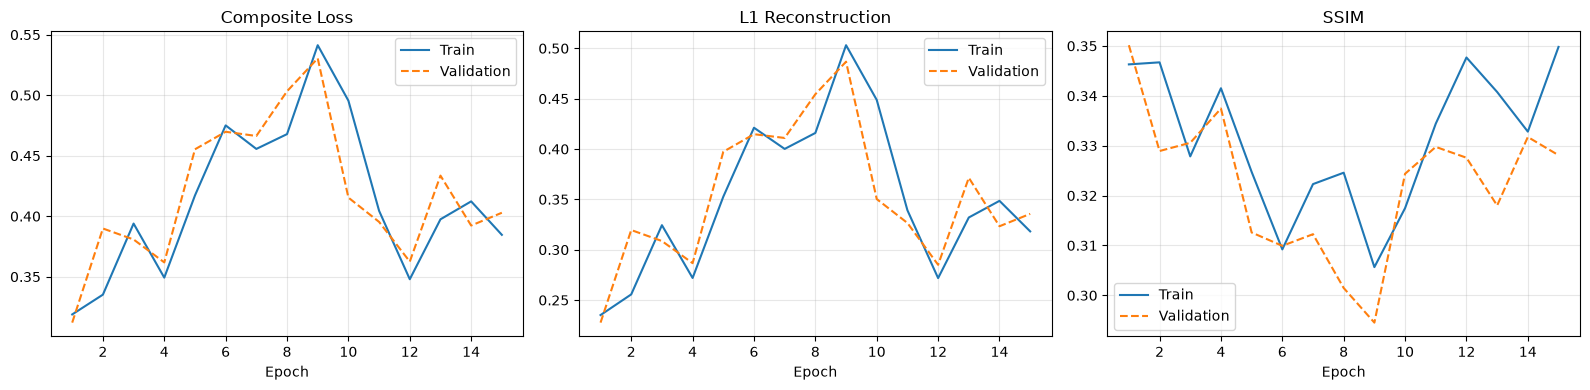

In [ ]:
# 8. Learning Curves
epochs_range = range(1, len(history["train_loss"]) + 1)
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, train_key, val_key, title in [
    (axes[0], "train_loss", "val_loss", "Composite Loss"),
    (axes[1], "recon_loss", "val_recon", "L1 Reconstruction"),
    (axes[2], "ssim", "val_ssim", "SSIM"),
]:
    ax.plot(epochs_range, history[train_key], label="Train")
    ax.plot(epochs_range, history[val_key], label="Validation", linestyle="--")
    ax.set(title=title, xlabel="Epoch")
    ax.grid(True, alpha=0.3)
    ax.legend()
plt.tight_layout()
plt.show()


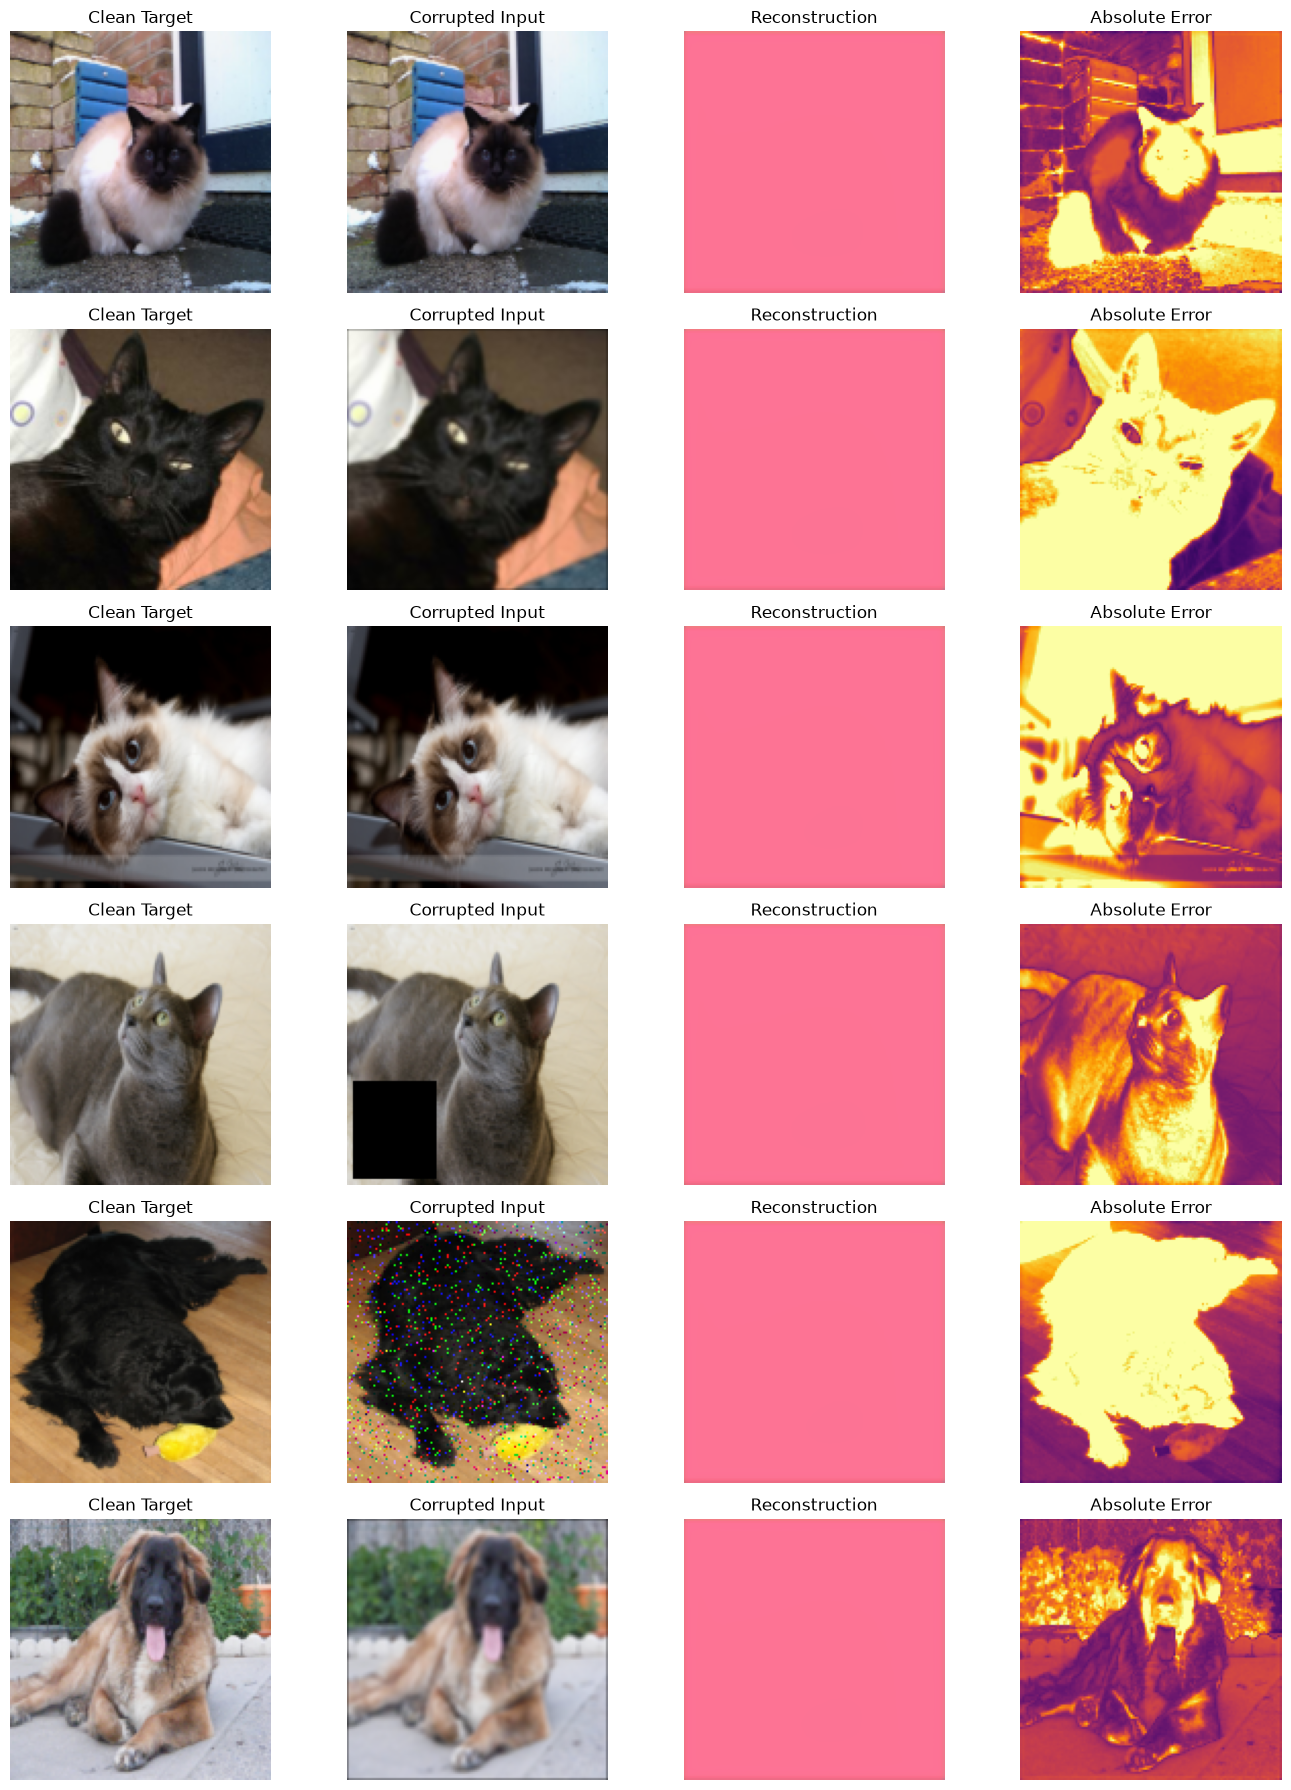

In [ ]:
# 9. Qualitative Visual Inspection Grid
model.eval()
val_batch_corrupted, val_batch_clean = next(iter(val_loader))
with torch.no_grad():
    recon_batch = model(val_batch_corrupted.to(device)).cpu()
num_display = min(6, len(val_batch_corrupted))
fig, axes = plt.subplots(num_display, 4, figsize=(14, 3 * num_display), squeeze=False)
for i in range(num_display):
    corrupted = val_batch_corrupted[i].permute(1, 2, 0).numpy().clip(0, 1)
    target = val_batch_clean[i].permute(1, 2, 0).numpy().clip(0, 1)
    output = recon_batch[i].permute(1, 2, 0).numpy().clip(0, 1)
    for col, image, title in [
        (0, target, "Clean Target"), (1, corrupted, "Corrupted Input"),
        (2, output, "Reconstruction"),
    ]:
        axes[i, col].imshow(image)
        axes[i, col].set_title(title)
        axes[i, col].axis("off")
    axes[i, 3].imshow(np.abs(target - output).mean(axis=-1), cmap="inferno", vmin=0, vmax=0.5)
    axes[i, 3].set_title("Absolute Error")
    axes[i, 3].axis("off")
plt.tight_layout()
plt.show()


## 10. Transition Gate Checklist (Plan 6 §1.4)
Before proceeding to `task1_dae_optuna.ipynb`, confirm that all criteria pass:
- [ ] Loss curves decrease reliably with no NaNs.
- [ ] Reconstructions visually reasonable across all 4 conditions (clean, salt, blur, occlusion).
- [ ] Checkpoint save/reload verified (`task1_universal_ae_best.pt` exists and loads cleanly).